In [2]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np

In [3]:
ds = xr.open_dataset('/glade/work/acruz/Caribbean_Heat_data/ERA5/dailymax_HI.nc')
ds

<xarray.Dataset> Size: 1GB
Dimensions:       (time: 31471, latitude: 82, longitude: 121)
Coordinates:
  * time          (time) datetime64[ns] 252kB 1940-01-01 ... 2026-02-28
  * latitude      (latitude) float64 656B 7.75 8.0 8.25 8.5 ... 27.5 27.75 28.0
  * longitude     (longitude) float64 968B -89.0 -88.75 -88.5 ... -59.25 -59.0
Data variables:
    HI_daily_max  (time, latitude, longitude) float32 1GB ...

In [4]:
HI_dmax_clim = ds.groupby('time.month').mean(dim='time')
HI_dmax_clim = HI_dmax_clim['HI_daily_max'].rename('HI_daily_max_clim')
HI_dmax_clim

<xarray.DataArray 'HI_daily_max_clim' (month: 12, latitude: 82, longitude: 121)> Size: 476kB
array([[[81.73619 , 82.009125, 82.31164 , ..., 88.55382 , 87.51154 ,
         84.7723  ],
        [81.28591 , 81.60505 , 81.984695, ..., 87.81528 , 84.59723 ,
         80.7987  ],
        [80.93819 , 81.207535, 81.52638 , ..., 82.65172 , 80.880394,
         81.27642 ],
        ...,
        [68.76475 , 68.87282 , 68.96759 , ..., 71.98395 , 71.965126,
         71.97872 ],
        [68.213295, 68.3059  , 68.38953 , ..., 71.73966 , 71.735756,
         71.73675 ],
        [67.673004, 67.75467 , 67.79713 , ..., 71.50493 , 71.49929 ,
         71.51573 ]],

       [[83.38064 , 83.682205, 83.97326 , ..., 88.833405, 87.743256,
         84.95135 ],
        [82.71673 , 83.07444 , 83.43196 , ..., 87.96022 , 84.730995,
         80.61409 ],
        [82.06271 , 82.39025 , 82.75269 , ..., 82.846695, 80.60874 ,
         80.89951 ],
...
        [74.27253 , 74.30794 , 74.36112 , ..., 76.45543 , 76.43271 ,
         76.445854],
        [73.89014 , 73.934044, 73.975105, ..., 76.25664 , 76.24046 ,
         76.234764],
        [73.53409 , 73.56217 , 73.565865, ..., 76.04459 , 76.03303 ,
         76.05203 ]],

       [[81.69688 , 81.84366 , 82.01464 , ..., 90.591286, 89.61244 ,
         86.81098 ],
        [81.61022 , 81.79805 , 82.005066, ..., 90.03958 , 86.55723 ,
         82.901245],
        [81.555954, 81.69102 , 81.87806 , ..., 84.6105  , 82.97228 ,
         83.58894 ],
        ...,
        [70.90201 , 70.97035 , 71.03966 , ..., 73.62648 , 73.61041 ,
         73.628586],
        [70.43856 , 70.49948 , 70.55778 , ..., 73.40391 , 73.40546 ,
         73.40842 ],
        [69.99593 , 70.050354, 70.06628 , ..., 73.18411 , 73.18912 ,
         73.21059 ]]], shape=(12, 82, 121), dtype=float32)
Coordinates:
  * month      (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * latitude   (latitude) float64 656B 7.75 8.0 8.25 8.5 ... 27.5 27.75 28.0
  * longitude  (longitude) float64 968B -89.0 -88.75 -88.5 ... -59.25 -59.0

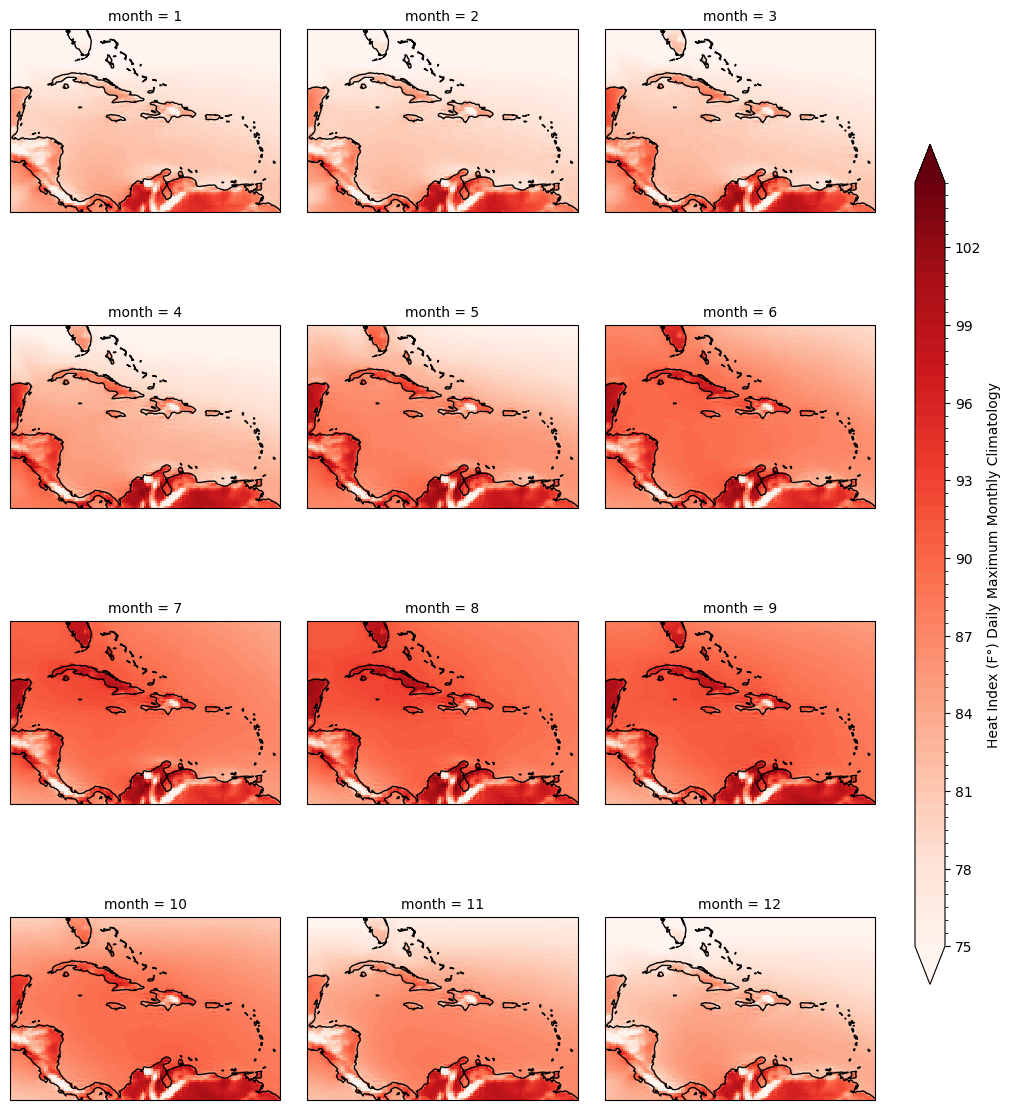

In [7]:
hiclim_plot = HI_dmax_clim.isel(month=np.arange(0, 12, 1)).plot(col='month',
                                                         col_wrap=3,
                                                         transform=ccrs.PlateCarree(),
                                                         cmap='Reds',
                                                         levels=np.arange(75, 105, 0.5),
                                                         subplot_kws={'projection': ccrs.PlateCarree(central_longitude=-70)},
                                                         add_colorbar=False
                                                               )
cax = hiclim_plot.fig.add_axes([0.92, 0.15, 0.03, 0.70])
hiclim_plot.fig.colorbar(hiclim_plot.axs.flat[0].collections[0], cax=cax, label='Heat Index (F°) Daily Maximum Monthly Climatology')
hiclim_plot.map(lambda: plt.gca().coastlines())
plt.subplots_adjust(wspace=0.1, hspace=0.05, right=0.88)

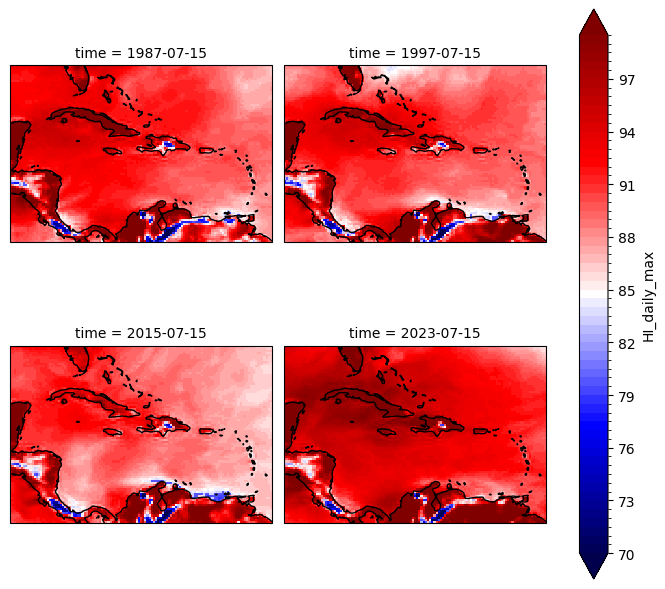

In [6]:
test_plot = ds['HI_daily_max'].sel(time=['1987-07-15', '1997-07-15', '2015-07-15', '2023-07-15'], method='nearest').plot(col='time', col_wrap=2,
                                                                                                                         transform=ccrs.PlateCarree(),
                                                                                                                         levels=np.arange(70,100, 0.5), cmap='seismic',
                                                                                                                         subplot_kws={'projection': ccrs.PlateCarree(central_longitude=-70)}
                                                                                                                         )
test_plot.map(lambda: plt.gca().coastlines())

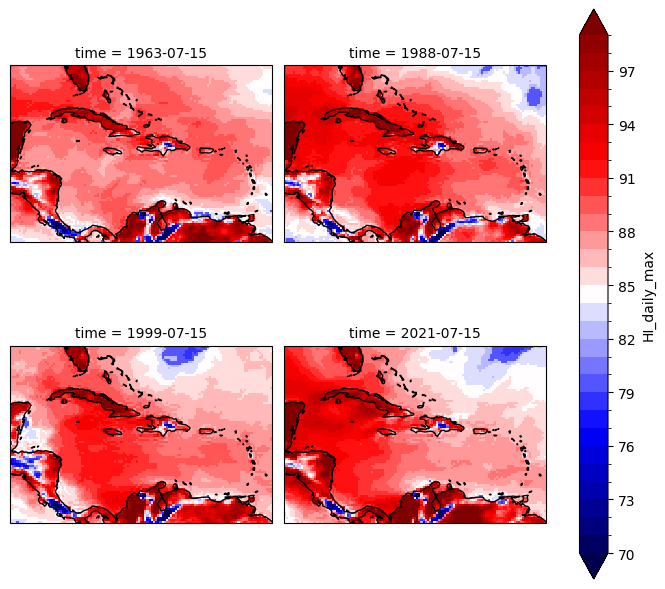

In [15]:
# ATL3 > 1.0
test_plot = ds['HI_daily_max'].sel(time=['1963-07-15', '1988-07-15', '1999-07-15', '2021-07-15'], method='nearest').plot(col='time', col_wrap=2,
                                                                                                                         transform=ccrs.PlateCarree(),
                                                                                                                         levels=np.arange(70,100), cmap='seismic',
                                                                                                                         subplot_kws={'projection': ccrs.PlateCarree(central_longitude=-70)}
                                                                                                                         )
test_plot.map(lambda: plt.gca().coastlines())

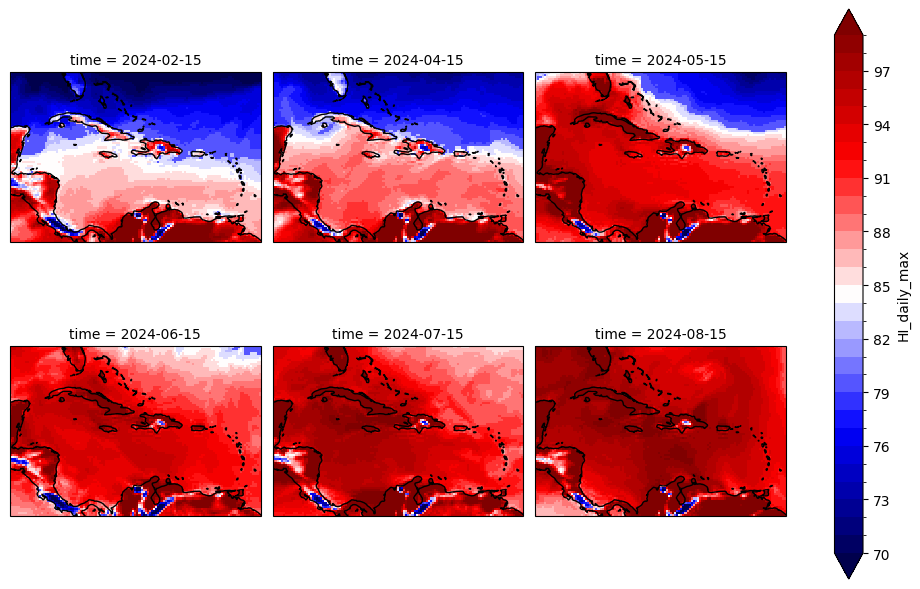

In [16]:
# 2024 AN
test_plot = ds['HI_daily_max'].sel(time=['2024-02-15', '2024-04-15', '2024-05-15', '2024-06-15', '2024-07-15', '2024-08-15'], method='nearest').plot(col='time', col_wrap=3,
                                                                                             transform=ccrs.PlateCarree(),
                                                                                             levels=np.arange(70,100), cmap='seismic',
                                                                                             subplot_kws={'projection': ccrs.PlateCarree(central_longitude=-70)}
                                                                                             )
test_plot.map(lambda: plt.gca().coastlines())

In [238]:
HI_dmax_clim.to_netcdf('/glade/work/acruz/Caribbean_Heat_data/ERA5/HI_dmaxclim.nc')